## Adding Wuhan Reference Genome to Regional Alignments

This section contains three similar functions that add the Wuhan reference genome sequence to your existing regional alignments (California, Texas, and New York). This is essential for rooting the phylogenetic trees and providing a common reference point for comparison.

The functions load the aligned sequences from each region, read the Wuhan reference sequence, pad it to match the alignment length (if necessary), and then write a new FASTA file containing all the regional sequences plus the Wuhan reference. This creates properly aligned datasets that include both the regional samples and the reference strain.

**Key steps in these functions:**

* Read the existing aligned sequences from each regional FASTA file
* Load the Wuhan reference sequence
* Pad the Wuhan sequence to match the alignment length
* Write a new FASTA file with all sequences including Wuhan

In [1]:
def add_wuhan_to_california():
    aligned_fasta_path = r"C:\Users\abhis\OneDrive\sem 4\BIO\CALIFORNIA\cal.fasta"
    wuhan_fasta_path = r"C:\Users\abhis\OneDrive\sem 4\BIO\EPI_ISL_402124.fasta"
    output_fasta_path = r"C:\Users\abhis\OneDrive\sem 4\BIO\CALIFORNIA\within_wuhan_california.fasta"
    wuhan_id = "Wuhan-Hu-1"

    # Load aligned sequences
    aligned_seqs = []
    with open(aligned_fasta_path, 'r') as f:
        seq = ""
        header = ""
        for line in f:
            if line.startswith(">"):
                if seq:
                    aligned_seqs.append((header, seq))
                    seq = ""
                header = line.strip()
            else:
                seq += line.strip().upper()
        if seq:
            aligned_seqs.append((header, seq))

    aln_len = len(aligned_seqs[0][1])
    print(f"✅ [California] Alignment length: {aln_len} bases")

    # Load Wuhan reference
    with open(wuhan_fasta_path, 'r') as f:
        wuhan_seq = "".join([line.strip().upper() for line in f if not line.startswith(">")])
    wuhan_padded = wuhan_seq.ljust(aln_len, '-')
    aligned_seqs.append((f">{wuhan_id}", wuhan_padded))

    with open(output_fasta_path, 'w') as f:
        for header, seq in aligned_seqs:
            f.write(f"{header}\n")
            for i in range(0, len(seq), 80):
                f.write(seq[i:i+80] + "\n")

    print(f"✅ Wuhan added to California alignment → {output_fasta_path}")


In [2]:
add_wuhan_to_california()

✅ [California] Alignment length: 29901 bases
✅ Wuhan added to California alignment → C:\Users\abhis\OneDrive\sem 4\BIO\CALIFORNIA\within_wuhan_california.fasta


In [3]:
def add_wuhan_to_texas():
    aligned_fasta_path = r"C:\Users\abhis\OneDrive\sem 4\BIO\TEXAS\tex.fasta"
    wuhan_fasta_path = r"C:\Users\abhis\OneDrive\sem 4\BIO\EPI_ISL_402124.fasta"
    output_fasta_path = r"C:\Users\abhis\OneDrive\sem 4\BIO\TEXAS\within_wuhan_texas.fasta"
    wuhan_id = "Wuhan-Hu-1"

    aligned_seqs = []
    with open(aligned_fasta_path, 'r') as f:
        seq = ""
        header = ""
        for line in f:
            if line.startswith(">"):
                if seq:
                    aligned_seqs.append((header, seq))
                    seq = ""
                header = line.strip()
            else:
                seq += line.strip().upper()
        if seq:
            aligned_seqs.append((header, seq))

    aln_len = len(aligned_seqs[0][1])
    print(f"✅ [Texas] Alignment length: {aln_len} bases")

    with open(wuhan_fasta_path, 'r') as f:
        wuhan_seq = "".join([line.strip().upper() for line in f if not line.startswith(">")])
    wuhan_padded = wuhan_seq.ljust(aln_len, '-')
    aligned_seqs.append((f">{wuhan_id}", wuhan_padded))

    with open(output_fasta_path, 'w') as f:
        for header, seq in aligned_seqs:
            f.write(f"{header}\n")
            for i in range(0, len(seq), 80):
                f.write(seq[i:i+80] + "\n")

    print(f"✅ Wuhan added to Texas alignment → {output_fasta_path}")


In [4]:
add_wuhan_to_texas()

✅ [Texas] Alignment length: 29898 bases
✅ Wuhan added to Texas alignment → C:\Users\abhis\OneDrive\sem 4\BIO\TEXAS\within_wuhan_texas.fasta


In [10]:
def add_wuhan_to_newyork():
    aligned_fasta_path = r"C:\Users\abhis\OneDrive\sem 4\BIO\NEWYORK\ney.fasta"
    wuhan_fasta_path = r"C:\Users\abhis\OneDrive\sem 4\BIO\EPI_ISL_402124.fasta"
    output_fasta_path = r"C:\Users\abhis\OneDrive\sem 4\BIO\NEWYORK\within_wuhan_newyork.fasta"
    wuhan_id = "Wuhan-Hu-1"

    aligned_seqs = []
    with open(aligned_fasta_path, 'r') as f:
        seq = ""
        header = ""
        for line in f:
            if line.startswith(">"):
                if seq:
                    aligned_seqs.append((header, seq))
                    seq = ""
                header = line.strip()
            else:
                seq += line.strip().upper()
        if seq:
            aligned_seqs.append((header, seq))

    aln_len = len(aligned_seqs[0][1])
    print(f"✅ [New York] Alignment length: {aln_len} bases")

    with open(wuhan_fasta_path, 'r') as f:
        wuhan_seq = "".join([line.strip().upper() for line in f if not line.startswith(">")])
    wuhan_padded = wuhan_seq.ljust(aln_len, '-')
    aligned_seqs.append((f">{wuhan_id}", wuhan_padded))

    with open(output_fasta_path, 'w') as f:
        for header, seq in aligned_seqs:
            f.write(f"{header}\n")
            for i in range(0, len(seq), 80):
                f.write(seq[i:i+80] + "\n")

    print(f"✅ Wuhan added to New York alignment → {output_fasta_path}")


In [11]:
add_wuhan_to_newyork()

✅ [New York] Alignment length: 29898 bases
✅ Wuhan added to New York alignment → C:\Users\abhis\OneDrive\sem 4\BIO\NEWYORK\within_wuhan_newyork.fasta


## Building Phylogenetic Trees Using Neighbor-Joining Method

This section implements the Neighbor-Joining (NJ) algorithm to construct phylogenetic trees from the aligned sequences. The NJ method is a bottom-up clustering approach that aims to minimize the total branch length at each step of the tree construction.

The process involves several key steps:

* Loading the aligned sequences from FASTA files into a dictionary
* Computing a distance matrix between all sequence pairs (based on sequence differences)
* Implementing the Neighbor-Joining algorithm to build the tree
* Writing the resulting tree in Newick format

**Key Components:**

* **Loading Sequences:** The `load_aligned_sequences` function parses FASTA files and extracts sequence identifiers and their corresponding nucleotide sequences.

* **Computing Distances:** The `compute_distance_matrix` function calculates pairwise distances between all sequences. It counts mismatches only at positions where both sequences have nucleotides (not gaps) and normalizes by the total number of comparable positions.

* **Neighbor-Joining Algorithm:** The `neighbor_joining` function implements the core algorithm:
    * Computes a Q-matrix that accounts for total distances to other nodes
    * Finds the pair with minimum Q-value to join
    * Creates a new node representing the joined pair
    * Recalculates distances to this new node
    * Iterates until only two nodes remain, then creates the final tree

* **Tree Building:** The `build_nj_tree_from_fasta` function orchestrates the entire process and outputs the Newick format tree.

In [12]:
def load_aligned_sequences(fasta_path):
    sequences = {}
    with open(fasta_path, 'r') as f:
        label = ""
        seq = ""
        for line in f:
            if line.startswith(">"):
                if label and seq:
                    sequences[label] = seq
                label = line.strip().replace(">", "")
                seq = ""
            else:
                seq += line.strip().upper()
        if label and seq:
            sequences[label] = seq
    print(f"✅ Loaded {len(sequences)} aligned sequences.")
    return sequences


In [13]:
def compute_distance_matrix(sequences):
    ids = list(sequences.keys())
    dist_matrix = {}
    for i in range(len(ids)):
        for j in range(i+1, len(ids)):
            id1, id2 = ids[i], ids[j]
            s1, s2 = sequences[id1], sequences[id2]
            mismatch = sum(1 for a, b in zip(s1, s2) if a != b and a != '-' and b != '-')
            total = sum(1 for a, b in zip(s1, s2) if a != '-' and b != '-')
            dist = mismatch / total if total > 0 else 0.0
            dist_matrix[(id1, id2)] = dist
            dist_matrix[(id2, id1)] = dist
    return dist_matrix, ids


In [15]:
def neighbor_joining(dist_matrix, ids):
    import copy
    from collections import defaultdict

    nodes = {id_: id_ for id_ in ids}
    D = copy.deepcopy(dist_matrix)
    current_ids = ids[:]
    tree = {}

    while len(current_ids) > 2:
        n = len(current_ids)
        # Compute Q-matrix
        total_d = {i: sum(D[(i, j)] for j in current_ids if j != i) for i in current_ids}
        Q = {}
        for i in current_ids:
            for j in current_ids:
                if i != j:
                    Q[(i, j)] = (n - 2) * D[(i, j)] - total_d[i] - total_d[j]

        # Find minimum Q
        (i, j), _ = min(Q.items(), key=lambda x: x[1])
        new_node = f"({nodes[i]},{nodes[j]})"

        # Update distances
        for k in current_ids:
            if k not in (i, j):
                dik = D[(i, k)]
                djk = D[(j, k)]
                D[(new_node, k)] = D[(k, new_node)] = (dik + djk - D[(i, j)]) / 2

        current_ids = [id_ for id_ in current_ids if id_ not in (i, j)] + [new_node]

        # Remove old distances
        for x in list(D.keys()):
            if i in x or j in x:
                del D[x]

        nodes[new_node] = new_node

    # Final join
    i, j = current_ids
    final_tree = f"({nodes[i]},{nodes[j]});"
    return final_tree


In [16]:
def build_nj_tree_from_fasta(fasta_path, output_path="tree.newick"):
    sequences = load_aligned_sequences(fasta_path)
    dist_matrix, ids = compute_distance_matrix(sequences)
    newick_tree = neighbor_joining(dist_matrix, ids)

    with open(output_path, "w") as f:
        f.write(newick_tree)

    print(f"🌳 Newick tree saved to: {output_path}")
    print(f"\n📎 Newick Format:\n{newick_tree}")


In [28]:
build_nj_tree_from_fasta(
    fasta_path=r"C:\Users\abhis\OneDrive\sem 4\BIO\CALIFORNIA\within_wuhan_california.fasta",
    output_path=r"C:\Users\abhis\OneDrive\sem 4\BIO\CALIFORNIA\treee_from_scratch.nwk"
)


✅ Loaded 194 aligned sequences.
🌳 Newick tree saved to: C:\Users\abhis\OneDrive\sem 4\BIO\CALIFORNIA\treee_from_scratch.nwk

📎 Newick Format:
((((['SRR16176084'],(['SRR15456782'],(['SRR16180165'],['SRR16180442']))),((((['SRR16173987'],(['SRR16174944'],(['SRR16174951'],(['SRR16174957'],(['SRR16176517'],(['SRR16174459'],['SRR16176518'])))))),(['SRR16174952'],(['SRR16175546'],['SRR16176573']))),(['SRR16176505'],(['SRR15024884'],((['SRR16180570'],['SRR16180523']),(['SRR15290356'],['SRR14391505']))))),((['SRR16180095'],(['SRR14374557'],(['SRR15550121'],((['SRR14391538'],['SRR14391539']),(['SRR14906413'],((['SRR15454621'],(['SRR15823052'],(['SRR15823024'],['SRR15380674']))),(['SRR15749061'],((['SRR15752132'],(['SRR15752131'],(['SRR15822885'],(['SRR15752134'],['SRR15749383'])))),((['SRR16732444'],['SRR16729217']),(['SRR15822695'],['SRR15138822'])))))))))),((['SRR15656422'],['SRR15917795']),((['SRR16180113'],['SRR15381039']),((['SRR14937269'],(['SRR15053269'],(['SRR15089247'],['SRR15748805']))

In [19]:
build_nj_tree_from_fasta(
    fasta_path=r"C:\Users\abhis\OneDrive\sem 4\BIO\TEXAS\within_wuhan_texas.fasta",
    output_path=r"C:\Users\abhis\OneDrive\sem 4\BIO\TEXAS\tree_from_scratch.nwk"
)


✅ Loaded 175 aligned sequences.
🌳 Newick tree saved to: C:\Users\abhis\OneDrive\sem 4\BIO\TEXAS\tree_from_scratch.nwk

📎 Newick Format:
((['SRR14393997'],((['SRR15053285'],['SRR14972386']),(['SRR14928841'],((['SRR15746247'],(['SRR15088707'],(((['SRR15752681'],(['SRR14928774'],['SRR14898311'])),(((['SRR16157135'],['SRR16062186']),(['SRR15363970'],(['SRR15550843'],['SRR15800270']))),(['SRR14398229'],(['SRR14896944'],['SRR14374504'])))),((['SRR15157182'],['SRR15156518']),(['SRR15382517'],(((['SRR15053516'],['SRR15053515']),(['SRR16341288'],(['SRR15053484'],(['SRR15157092'],['SRR15749727'])))),((['SRR14880549'],['SRR15752657']),(['SRR15363655'],((['SRR15552675'],['SRR15821796']),(['SRR15822938'],(['SRR15822987'],['SRR15822439']))))))))))),(((((['SRR15378306'],(['SRR15494168'],(['SRR16340187'],['SRR15089438']))),((['SRR15456126'],(['SRR15231804'],['SRR15089428'])),(['SRR15489493'],(((['SRR14880572'],['SRR15752079']),(['SRR15156511'],(['SRR15053479'],(['SRR15749708'],['SRR15053480'])))),(['S

In [20]:
build_nj_tree_from_fasta(
    fasta_path=r"C:\Users\abhis\OneDrive\sem 4\BIO\NEWYORK\within_wuhan_newyork.fasta",
    output_path=r"C:\Users\abhis\OneDrive\sem 4\BIO\NEWYORK\tree_from_scratch.nwk"
)


✅ Loaded 63 aligned sequences.
🌳 Newick tree saved to: C:\Users\abhis\OneDrive\sem 4\BIO\NEWYORK\tree_from_scratch.nwk

📎 Newick Format:
((((['SRR14908668'],(['SRR14894899'],['SRR14955943'])),(((['SRR14973889'],(['SRR15231235'],['SRR15089000'])),(['SRR15089004'],(['SRR14928687'],((['SRR14908784'],['SRR14908776']),(['SRR14926725'],(['SRR14910489'],(['SRR15023178'],['SRR14937381']))))))),((['SRR15232475'],['SRR15799908']),(['SRR24192965'],['SRR15026199'])))),((['SRR24192463'],['SRR24194238']),(['SRR15026177'],(['SRR24191499'],['SRR24192456'])))),((['SRR15646688'],(['SRR15157450'],(['SRR24192472'],['SRR14898464']))),(((['SRR14811866'],['SRR14898248']),((['SRR14938539'],['SRR14895537']),(['SRR14912891'],['SRR14898217']))),((['SRR14911771'],(['SRR15379825'],['SRR14927971'])),(((((['SRR15088495'],(['SRR14912480'],(['SRR16342126'],(['SRR14927311'],((nan,['SRR14989427']),(['SRR14989292'],(['SRR14910073'],(['SRR14987372'],['SRR14894854'])))))))),(['SRR14908782'],(['SRR14392640'],(['SRR14927352'

## Visualizing Phylogenetic Trees

This final section uses Biopython's `Phylo` module and `matplotlib` to visualize the phylogenetic trees created in the previous step. The function `visualize_tree_polished` loads a Newick-format tree file and creates a clear, visually appealing representation of the evolutionary relationships.

The visualization process includes:

* Reading the tree file using Biopython's `Phylo` module
* Formatting the tree labels for better readability (shortening names, highlighting reference sequences)
* Creating a large figure with appropriate dimensions for complex trees
* Drawing the tree with customized styling
* Adjusting label properties for improved legibility
* Hiding unnecessary axis elements for a cleaner appearance

This visualization helps in interpreting the evolutionary relationships between different SARS-CoV-2 sequences across the three U.S. regions and their relationship to the Wuhan reference strain.

In [36]:
from Bio import Phylo
import matplotlib.pyplot as plt

def visualize_tree_polished(tree_path, region_name="Region"):
    tree = Phylo.read(tree_path, "newick")

    # Optional: Shorten long names (optional post-label fix)
    for clade in tree.find_clades():
        if clade.name:
            if "wuhan" in clade.name.lower():
                clade.name = "Wuhan"
            elif "SRR" in clade.name:
                clade.name = clade.name.replace("SRR", "")  # Shorten SRR IDs

    # Plot settings
    fig = plt.figure(figsize=(18, 30))  # Taller for large trees
    ax = fig.add_subplot(1, 1, 1)
    ax.set_title(f"🌳 Phylogenetic Tree — {region_name}", fontsize=18, weight='bold')

    # Draw the tree
    Phylo.draw(
        tree,
        axes=ax,
        do_show=False,
        label_func=lambda x: x.name if x.name else "",
        branch_labels=None,  # Hide branch lengths
        show_confidence=False
    )

    # Improve label font size
    for label in ax.get_yticklabels():
        label.set_fontsize(8)  # Smaller labels
        label.set_rotation(0)  # Straight text

    # Optional: Hide x/y ticks
    ax.set_xticks([])
    ax.set_yticks([])

    plt.box(False)
    plt.tight_layout()
    plt.show()


C:\Users\abhis\AppData\Local\Temp\ipykernel_5976\2361871330.py:40: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


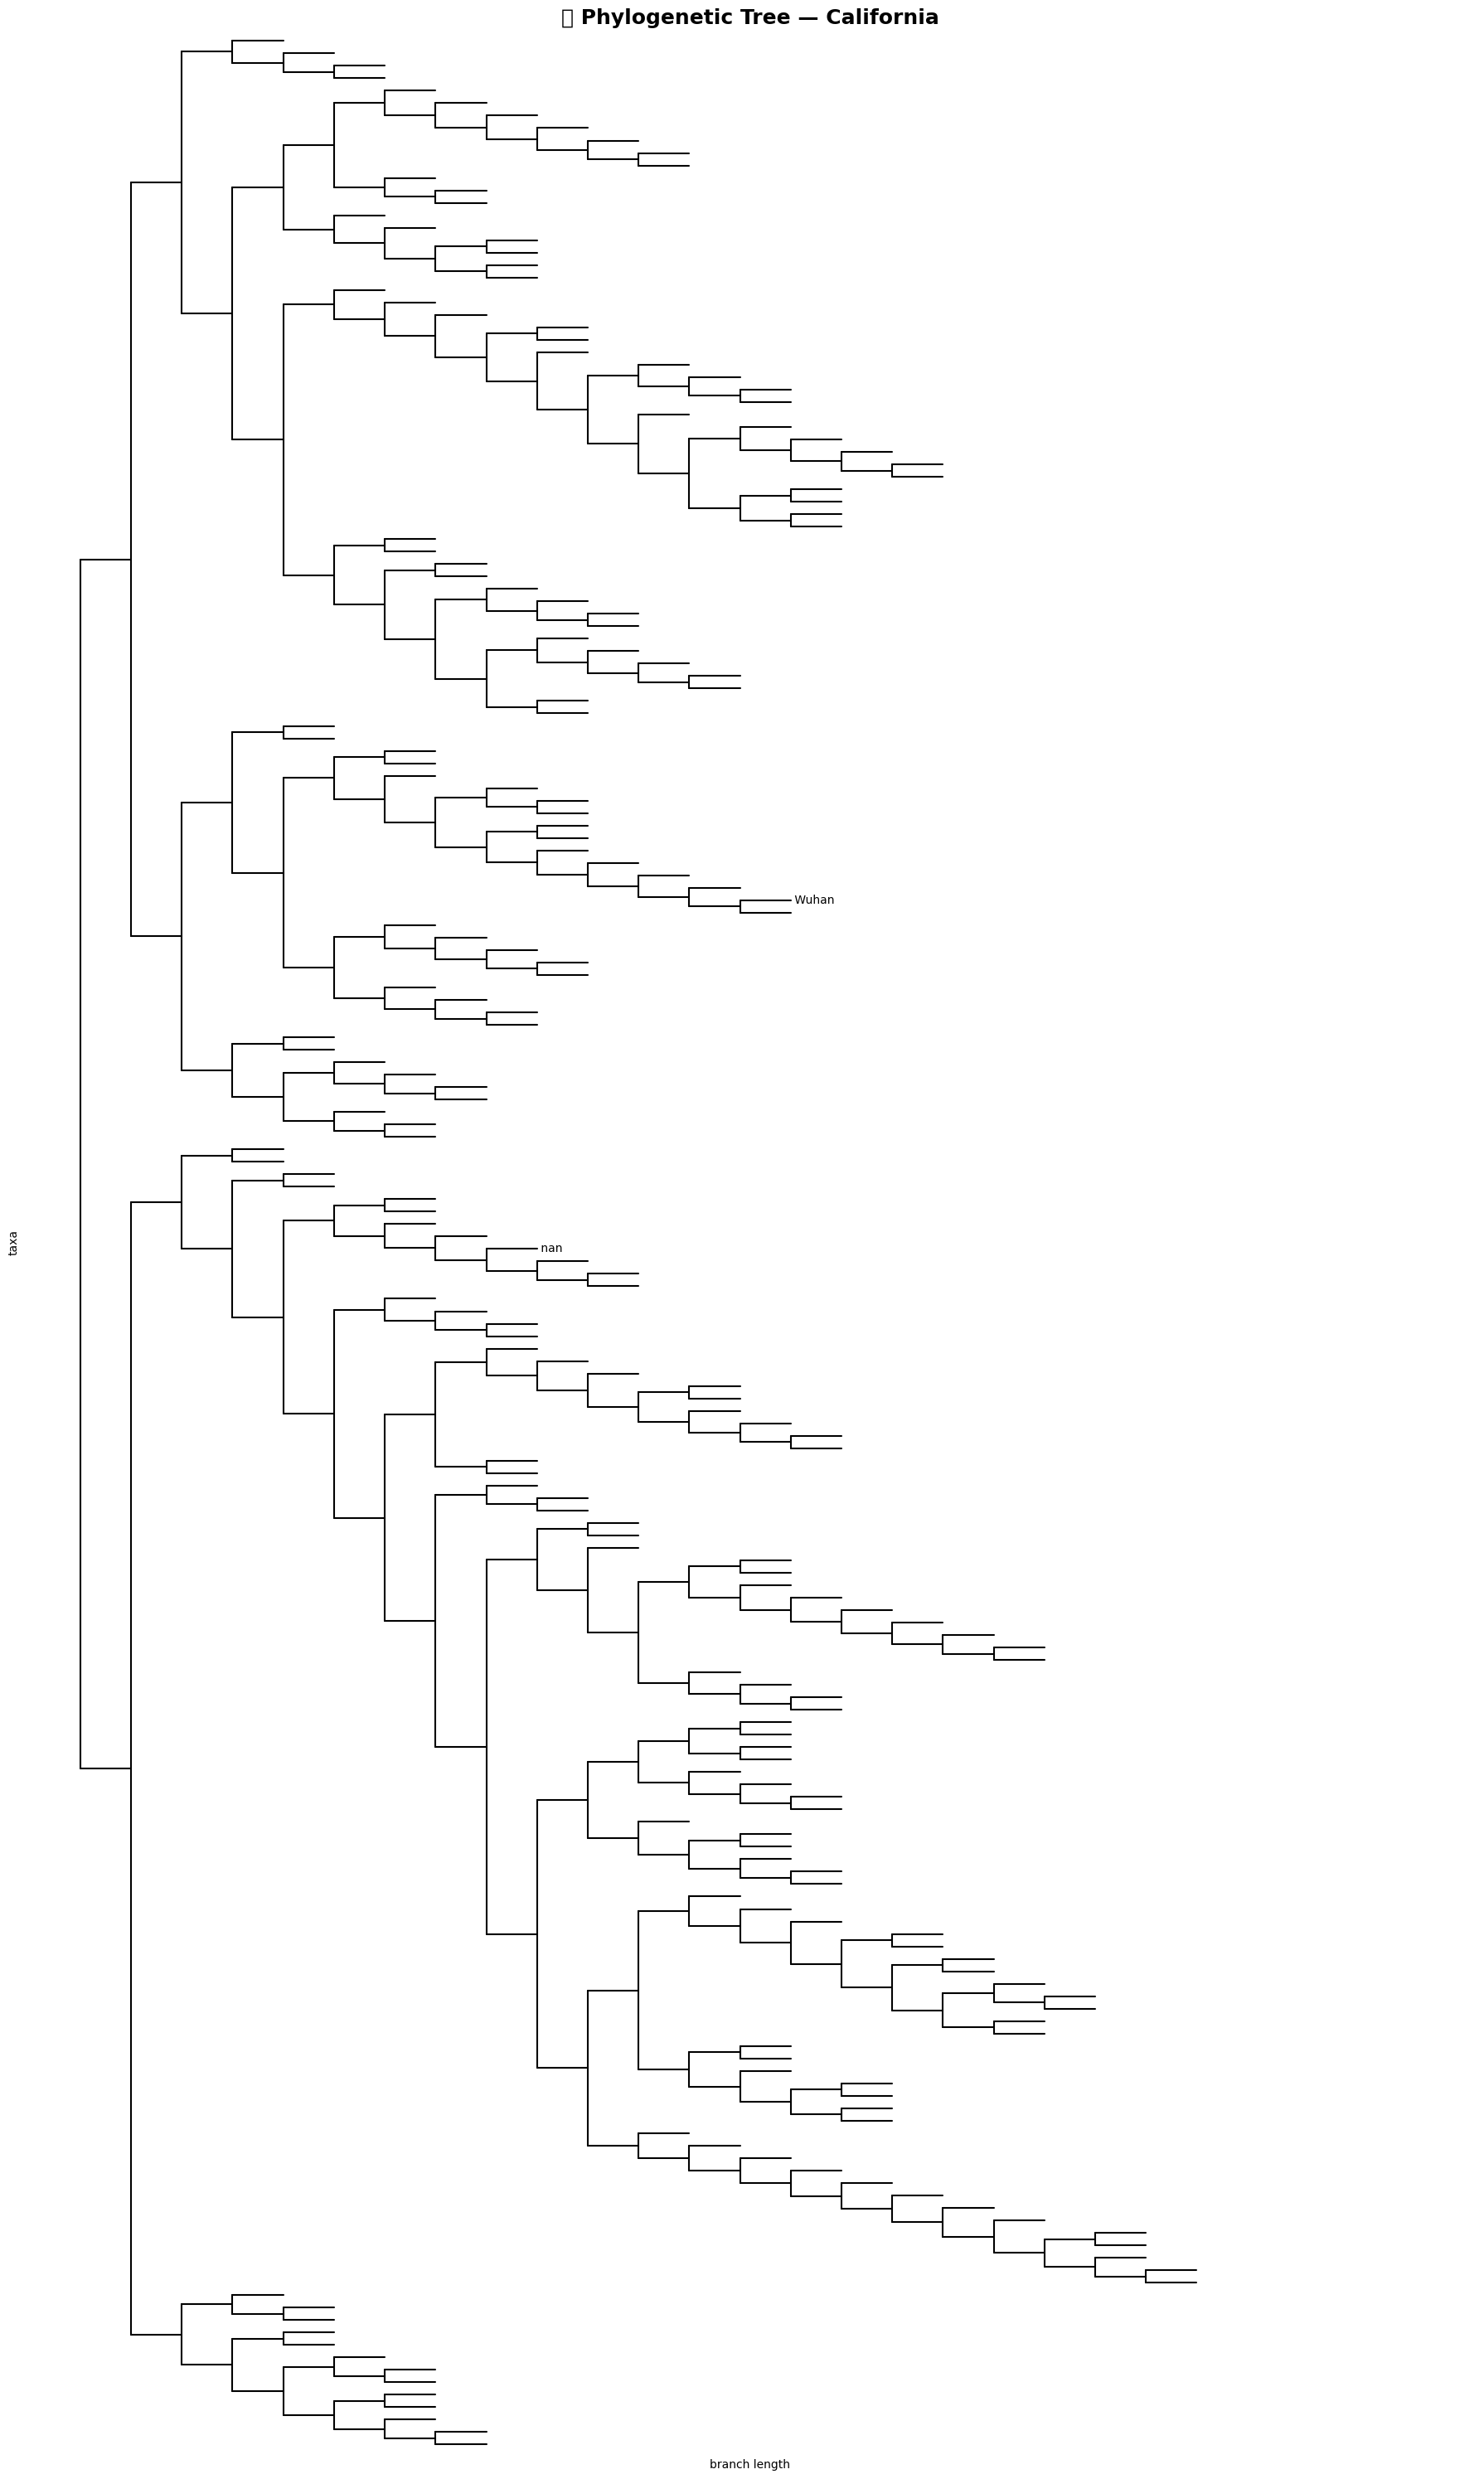

In [37]:
visualize_tree_polished(
    tree_path=r"C:\Users\abhis\OneDrive\sem 4\BIO\CALIFORNIA\treee_from_scratch.nwk",
    region_name="California"
)


C:\Users\abhis\AppData\Local\Temp\ipykernel_5976\2361871330.py:40: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


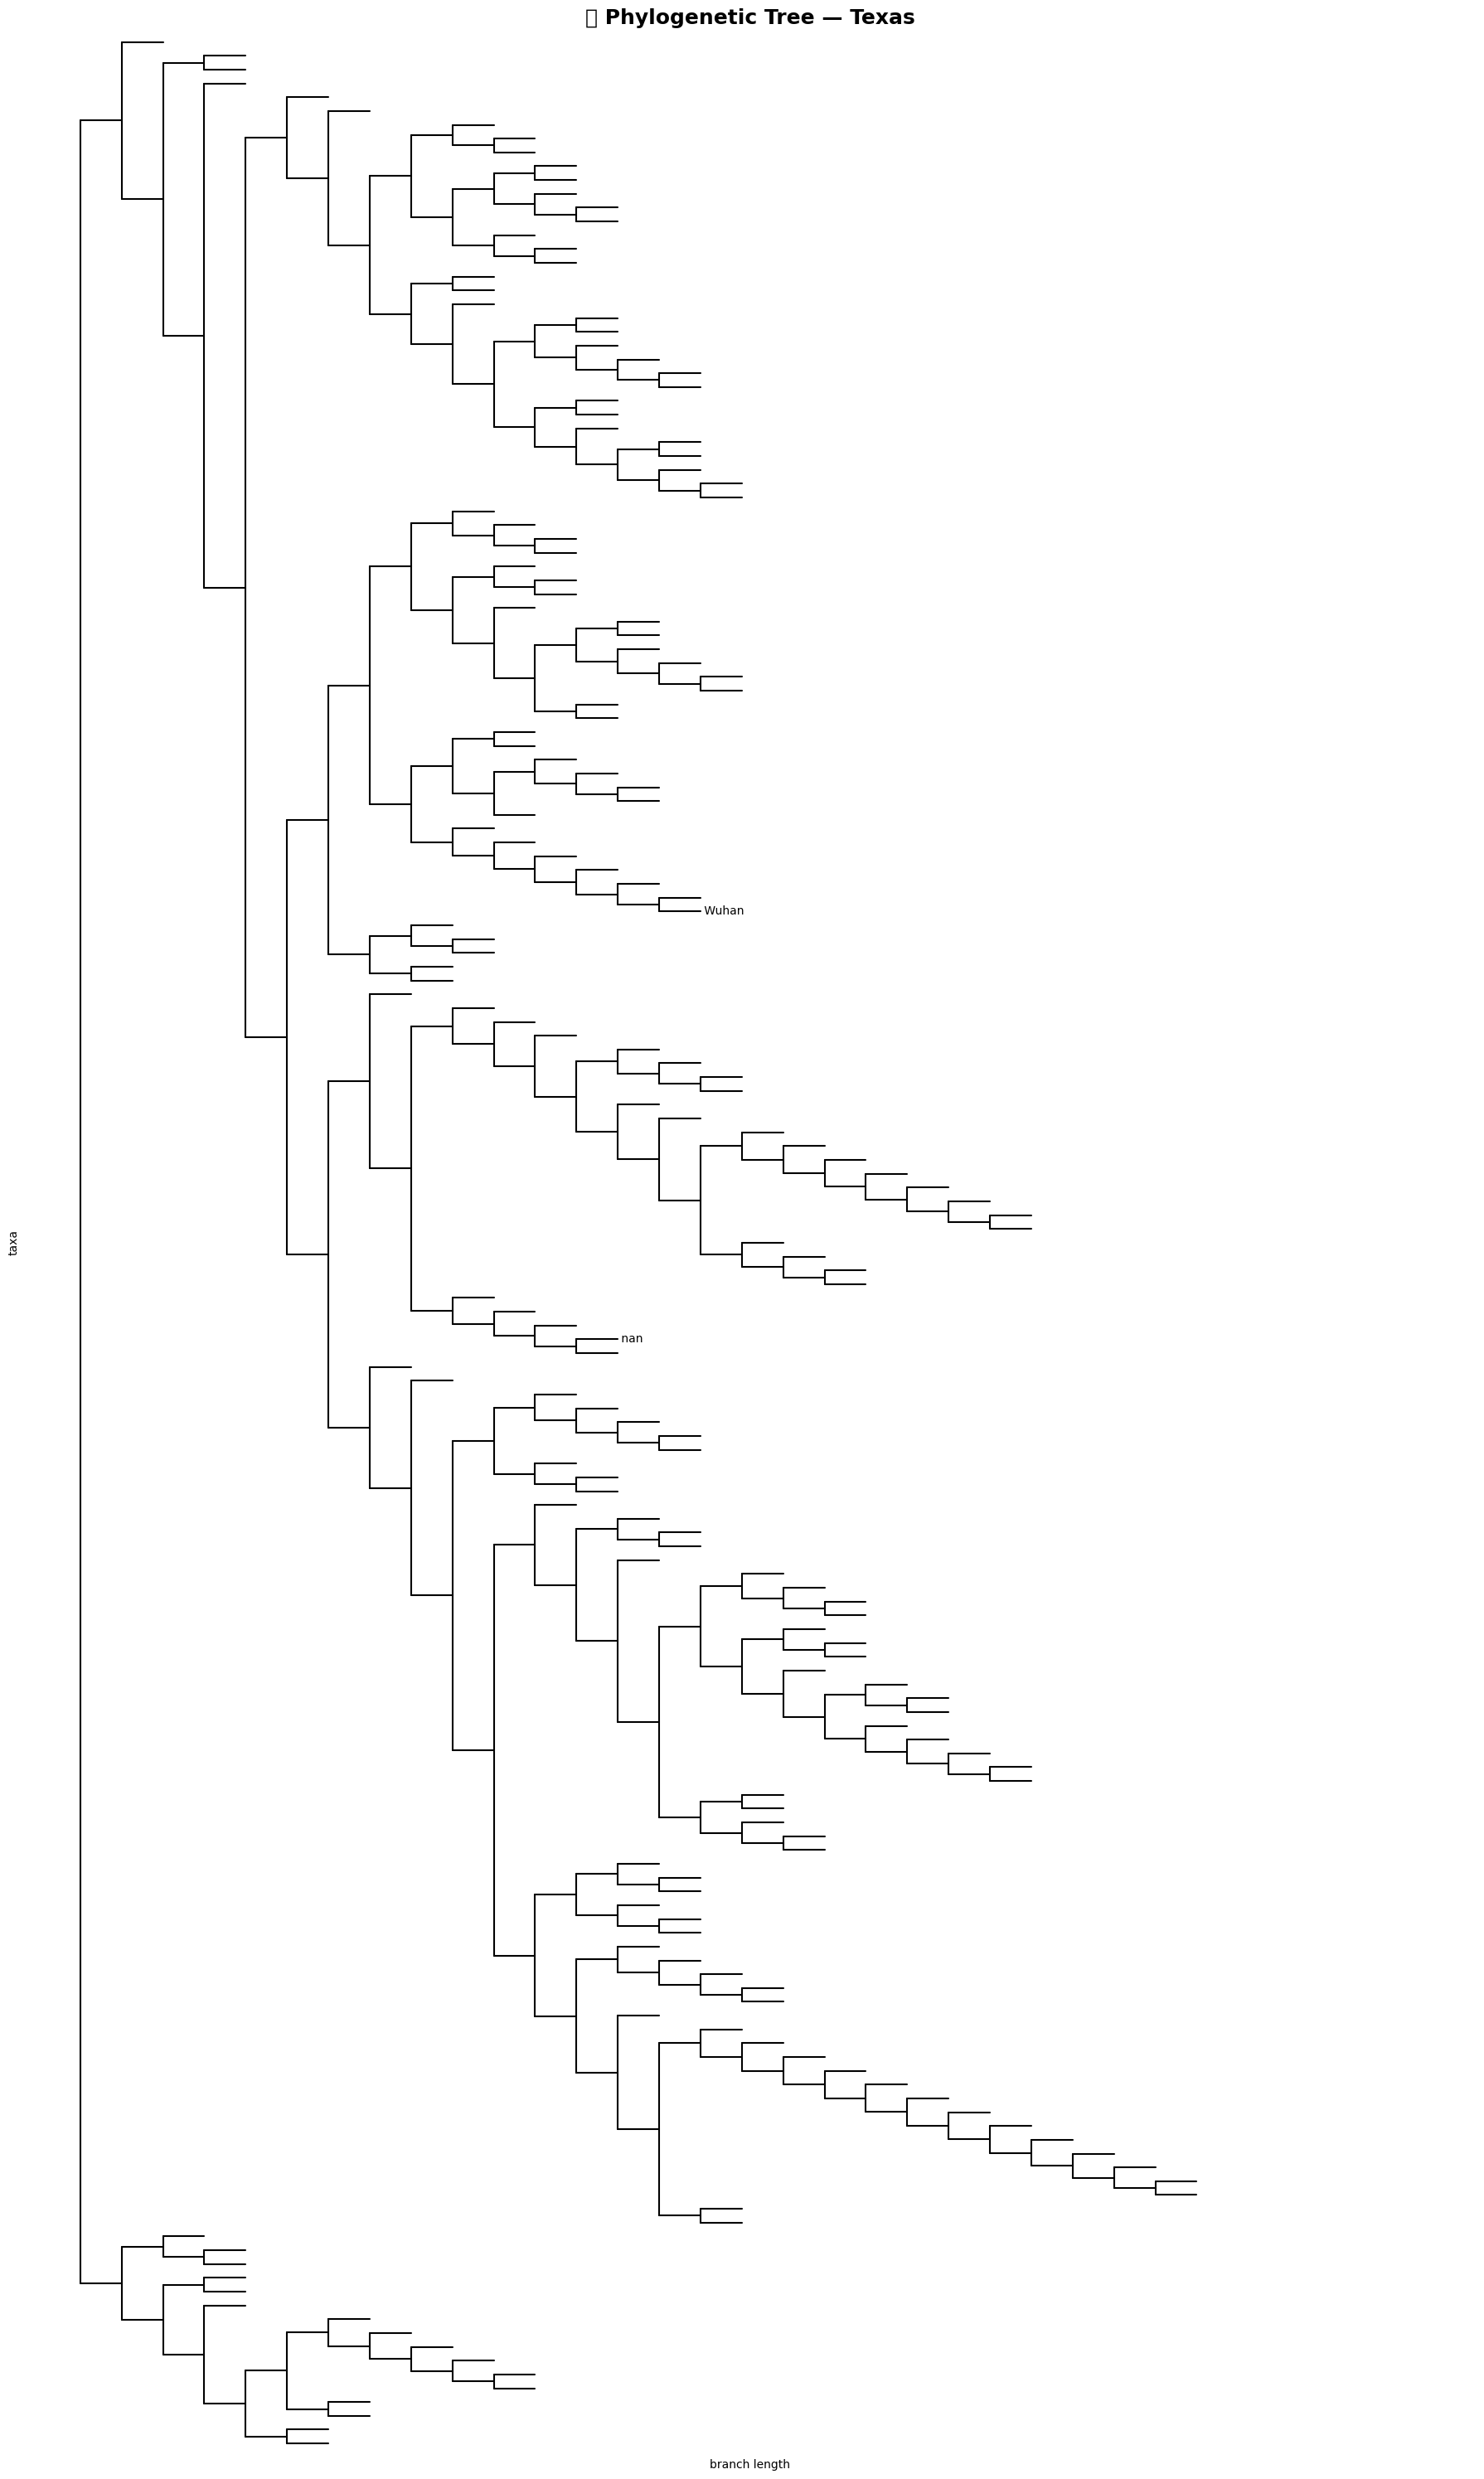

In [24]:
visualize_tree_polished(
    tree_path=r"C:\Users\abhis\OneDrive\sem 4\BIO\TEXAS\tree_from_scratch.nwk",
    region_name="Texas"
)


C:\Users\abhis\AppData\Local\Temp\ipykernel_5976\2361871330.py:40: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


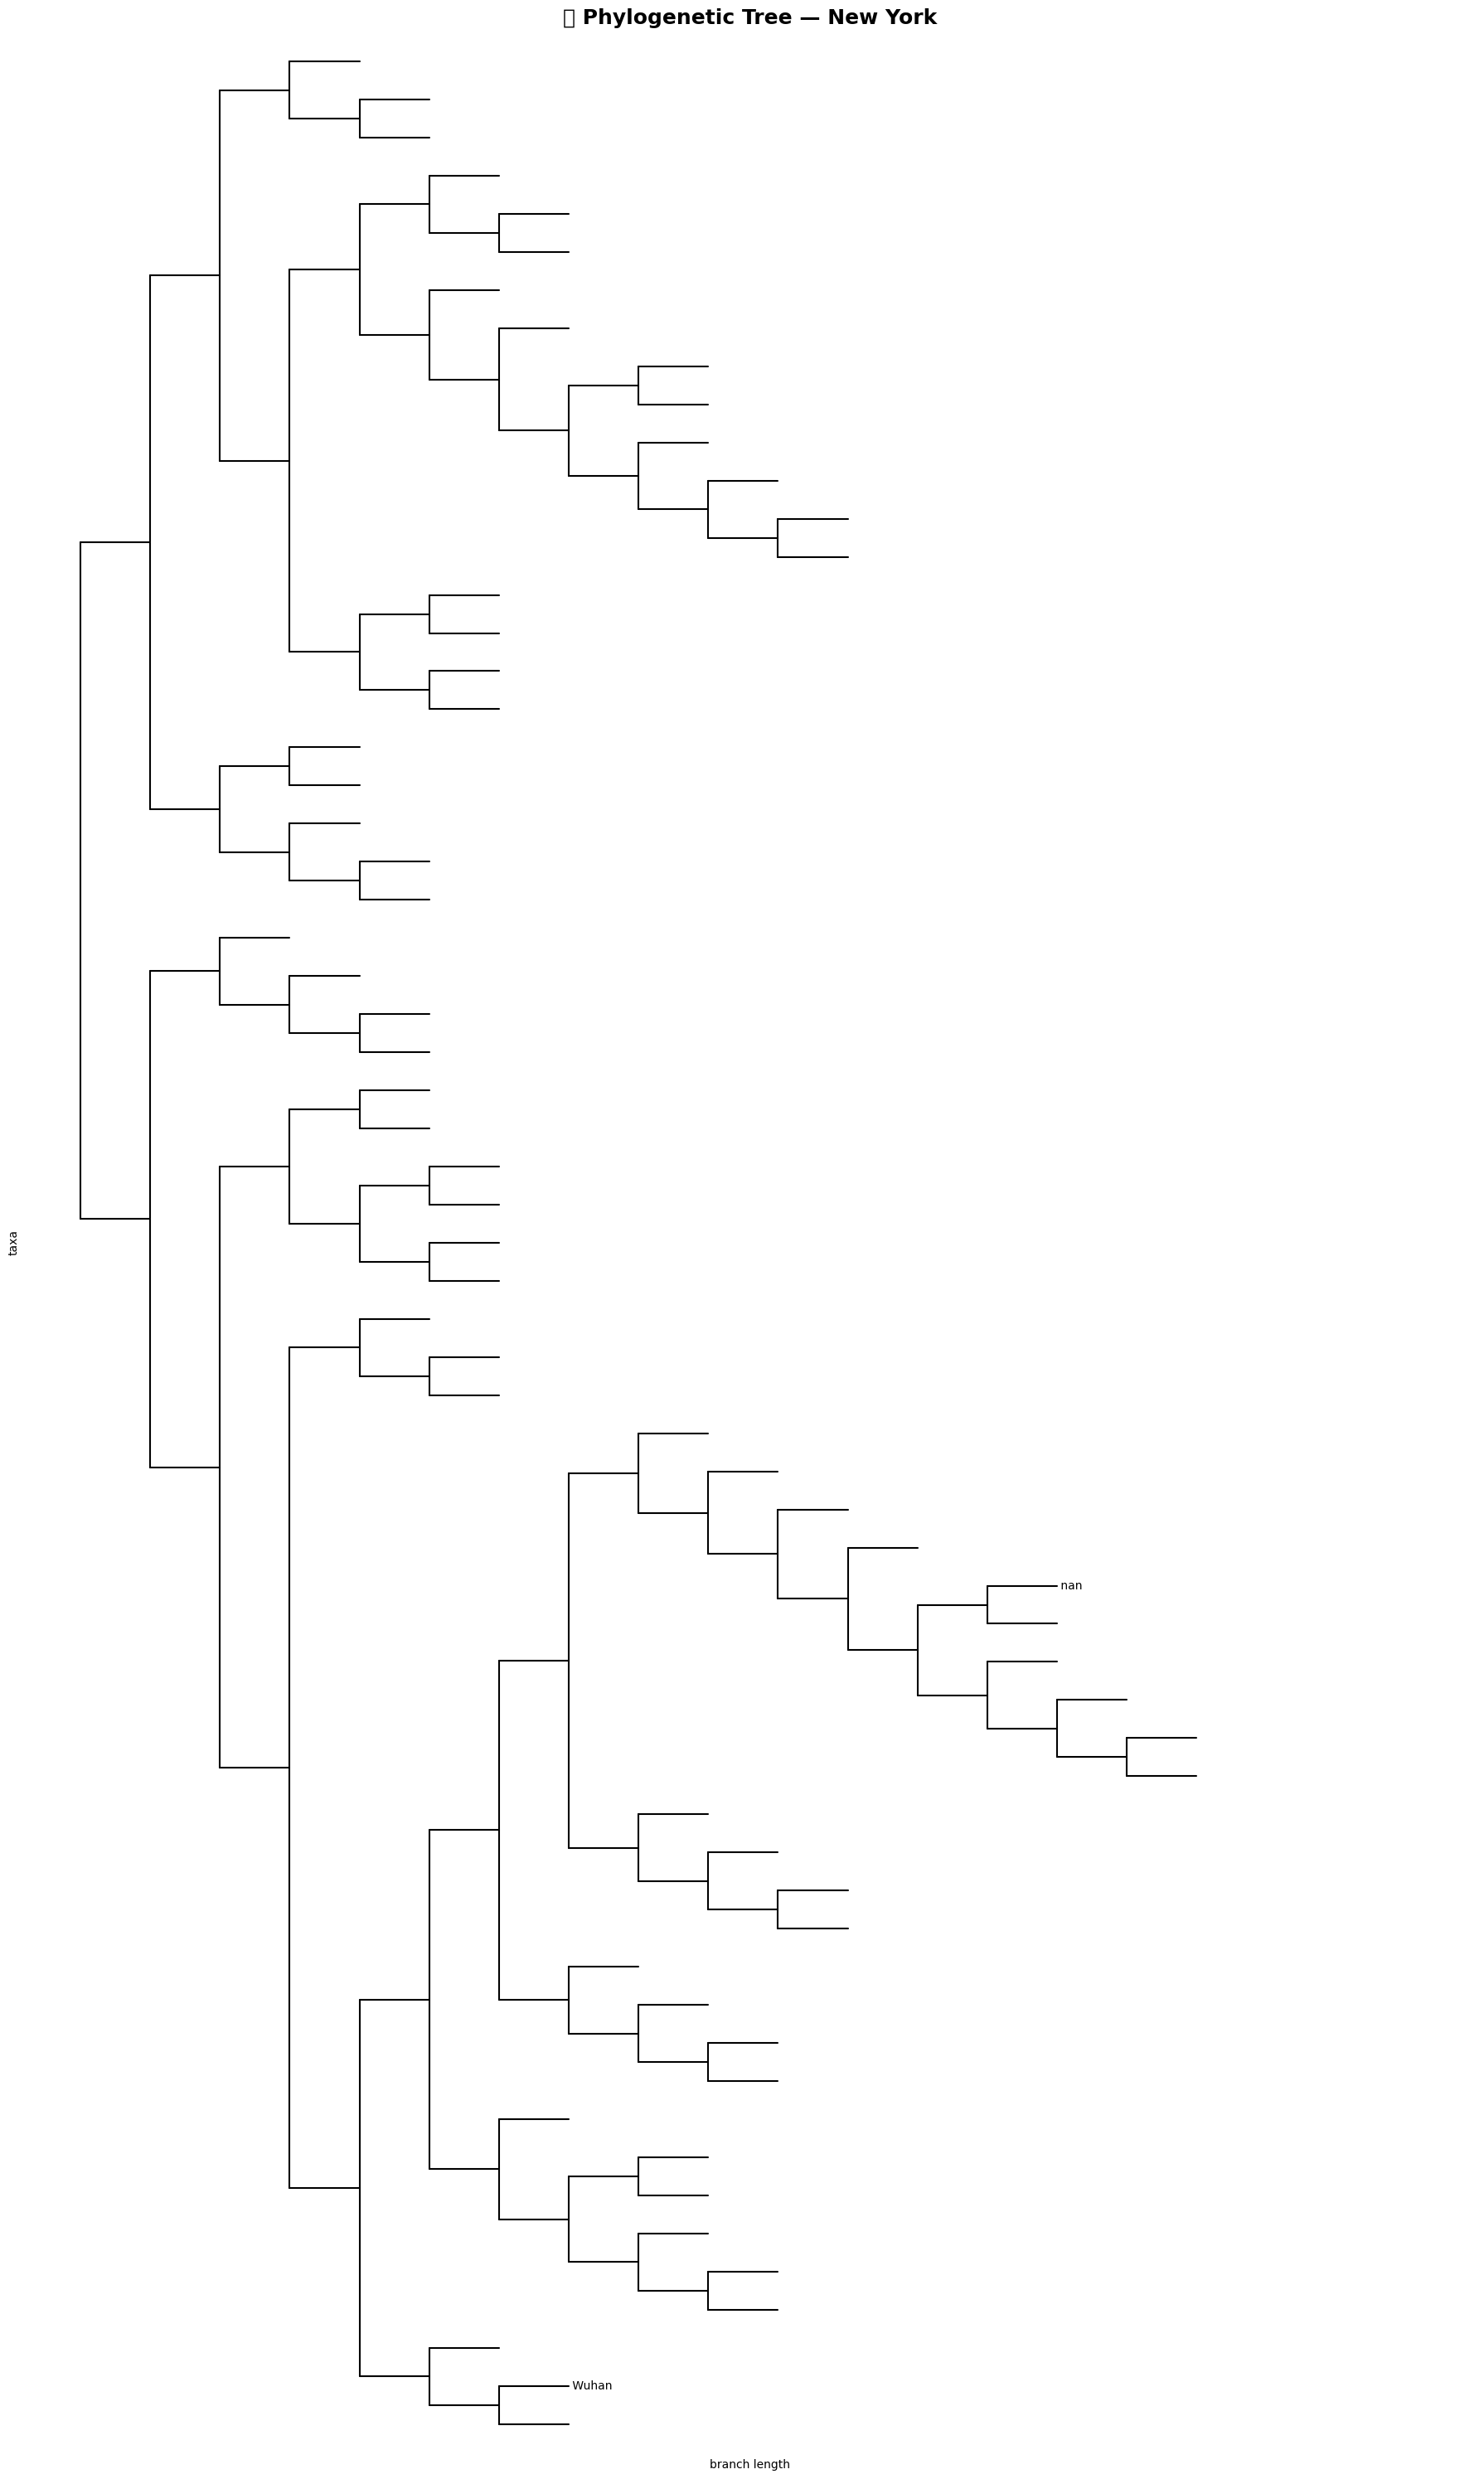

In [25]:
visualize_tree_polished(
    tree_path=r"C:\Users\abhis\OneDrive\sem 4\BIO\NEWYORK\tree_from_scratch.nwk",
    region_name="New York"
)


In [ ]:
from Bio import SeqIO, pairwise2
from Bio.pairwise2 import format_alignment
import os

# Define paths to consensus FASTA files
city_paths = {
    "New York": r"C:\Users\abhis\OneDrive\sem 4\BIO\NEWYORK\consensus_newyork.fasta",
    "Texas": r"C:\Users\abhis\OneDrive\sem 4\BIO\TEXAS\consensus_texas.fasta",
    "California": r"C:\Users\abhis\OneDrive\sem 4\BIO\CALIFORNIA\consensus_california.fasta"
}

# Function to read a consensus sequence from a FASTA file
def read_consensus_sequence(fasta_path):
    try:
        record = next(SeqIO.parse(fasta_path, "fasta"))
        return str(record.seq)
    except Exception as e:
        print(f"❌ Error reading {fasta_path}: {e}")
        return None

# Store sequences by city
city_sequences = {}

print("📥 Loading consensus sequences...\n")
for city, path in city_paths.items():
    seq = read_consensus_sequence(path)
    if seq:
        print(f"✅ Loaded: {city} — {len(seq)} bases")
        city_sequences[city] = seq
    else:
        print(f"❌ Failed to load: {city}")

print("\n🔬 Performing Global Pairwise Alignments...\n")

# Perform pairwise alignments
results = []

cities = list(city_sequences.keys())
for i in range(len(cities)):
    for j in range(i+1, len(cities)):
        city1, city2 = cities[i], cities[j]
        seq1, seq2 = city_sequences[city1], city_sequences[city2]

        alignment = pairwise2.align.globalms(seq1, seq2, 2, -1, -2, -0.5, one_alignment_only=True)[0]
        score = alignment.score
        aligned_seq1 = alignment.seqA
        aligned_seq2 = alignment.seqB

        # Count mismatches (excluding gaps)
        mismatches = sum(1 for a, b in zip(aligned_seq1, aligned_seq2) if a != b and a != '-' and b != '-')

        results.append({
            "pair": f"{city1} vs {city2}",
            "score": score,
            "mismatches": mismatches,
            "alignment_length": len(aligned_seq1)
        })

# Display results
print("📊 Alignment Summary:\n")
for res in results:
    print(f"{res['pair']}")
    print(f"  🔹 Score       : {res['score']:.2f}")
    print(f"  🔹 Mismatches  : {res['mismatches']}")
    print(f"  🔹 Aln Length  : {res['alignment_length']}")
    print()

# Optional: Rank cities by total mismatch count
city_mismatch_counts = {city: 0 for city in cities}
for res in results:
    city1, city2 = res['pair'].split(" vs ")
    city_mismatch_counts[city1] += res['mismatches']
    city_mismatch_counts[city2] += res['mismatches']

print("🏆 Disease Proneness Estimate (based on total mismatches):")
sorted_ranking = sorted(city_mismatch_counts.items(), key=lambda x: x[1], reverse=True)
for rank, (city, total_mismatch) in enumerate(sorted_ranking, start=1):
    print(f"{rank}. {city}: {total_mismatch} total mismatches")



c:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


📥 Loading consensus sequences...

✅ Loaded: New York — 29898 bases
✅ Loaded: Texas — 29898 bases
✅ Loaded: California — 29901 bases

🔬 Performing Global Pairwise Alignments...



In [1]:
def parse_newick_tree(newick):
    import re

    def recursive_parse(subtree, depth=0, branch_dict=None):
        if branch_dict is None:
            branch_dict = {}

        # Remove outer parentheses
        if subtree.startswith("(") and subtree.endswith(";"):
            subtree = subtree[:-1]
        if subtree.startswith("(") and subtree.endswith(")"):
            subtree = subtree[1:-1]

        # Split outermost comma-separated parts
        stack, parts = [], []
        temp = ""
        for ch in subtree:
            if ch == "(":
                stack.append(ch)
            elif ch == ")":
                if stack:
                    stack.pop()
            elif ch == "," and not stack:
                parts.append(temp.strip())
                temp = ""
                continue
            temp += ch
        if temp:
            parts.append(temp.strip())

        for part in parts:
            if part.startswith("("):
                recursive_parse(part, depth + 1, branch_dict)
            else:
                leaf = re.split(r'[:]', part)[0].strip()
                branch_dict[leaf] = depth

        return branch_dict  # ✅ THIS LINE WAS MISSING

    return recursive_parse(newick)


In [2]:
def analyze_drift_from_wuhan(newick_path, region_name="Region"):
    with open(newick_path, "r") as f:
        newick = f.read().strip()

    branch_depths = parse_newick_tree(newick)
    wuhan_label = [k for k in branch_depths if "wuhan" in k.lower() or "Wuhan-Hu-1" in k]
    
    if not wuhan_label:
        print("❌ Wuhan reference not found in tree.")
        return

    wuhan = wuhan_label[0]
    print(f"🧬 Wuhan node: {wuhan}")

    drift = {}
    for node, depth in branch_depths.items():
        if node != wuhan:
            drift[node] = abs(depth - branch_depths[wuhan])

    print(f"\n📊 {region_name} Clade Drift Summary:")
    print(f"→ Total samples: {len(drift)}")

    sorted_drift = sorted(drift.items(), key=lambda x: x[1], reverse=True)
    for node, d in sorted_drift[:5]:
        print(f"   - {node} → drift = {d}")

    avg = sum(drift.values()) / len(drift)
    print(f"\n📈 Mean Drift from Wuhan ({region_name}): {avg:.2f} branches")

    return drift


In [8]:
analyze_drift_from_wuhan(
    newick_path=r"C:\Users\abhis\OneDrive\sem 4\BIO\CALIFORNIA\tree_from_scratch.nwk",
    region_name="California"
)


🧬 Wuhan node: Wuhan-Hu-1

📊 California Clade Drift Summary:
→ Total samples: 193
   - ['SRR16176084'] → drift = 10
   - ['SRR15795875'] → drift = 10
   - ['SRR15088819'] → drift = 10
   - ['SRR16174968'] → drift = 10
   - ['SRR15456782'] → drift = 9

📈 Mean Drift from Wuhan (California): 4.17 branches


{"['SRR16176084']": 10,
 "['SRR15456782']": 9,
 "['SRR16180165']": 8,
 "['SRR16180442']": 8,
 "['SRR16173987']": 7,
 "['SRR16174944']": 6,
 "['SRR16174951']": 5,
 "['SRR16174957']": 4,
 "['SRR16176517']": 3,
 "['SRR16174459']": 2,
 "['SRR16176518']": 2,
 "['SRR16174952']": 7,
 "['SRR16175546']": 6,
 "['SRR16176573']": 6,
 "['SRR16176505']": 8,
 "['SRR15024884']": 7,
 "['SRR16180570']": 5,
 "['SRR16180523']": 5,
 "['SRR15290356']": 5,
 "['SRR14391505']": 5,
 "['SRR16180095']": 8,
 "['SRR14374557']": 7,
 "['SRR15550121']": 6,
 "['SRR14391538']": 4,
 "['SRR14391539']": 4,
 "['SRR14906413']": 4,
 "['SRR15454621']": 2,
 "['SRR15823052']": 1,
 "['SRR15823024']": 0,
 "['SRR15380674']": 0,
 "['SRR15749061']": 2,
 "['SRR15752132']": 0,
 "['SRR15752131']": 1,
 "['SRR15822885']": 2,
 "['SRR15752134']": 3,
 "['SRR15749383']": 3,
 "['SRR16732444']": 1,
 "['SRR16729217']": 1,
 "['SRR15822695']": 1,
 "['SRR15138822']": 1,
 "['SRR15656422']": 7,
 "['SRR15917795']": 7,
 "['SRR16180113']": 6,
 "['SRR153

In [7]:
analyze_drift_from_wuhan(
    newick_path=r"C:\Users\abhis\OneDrive\sem 4\BIO\TEXAS\tree_from_scratch.nwk",
    region_name="Texas"
)


🧬 Wuhan node: Wuhan-Hu-1

📊 Texas Clade Drift Summary:
→ Total samples: 174
   - ['SRR14393997'] → drift = 13
   - ['SRR15744953'] → drift = 12
   - ['SRR14898283'] → drift = 12
   - ['SRR15266440'] → drift = 12
   - ['SRR15053285'] → drift = 11

📈 Mean Drift from Wuhan (Texas): 3.91 branches


{"['SRR14393997']": 13,
 "['SRR15053285']": 11,
 "['SRR14972386']": 11,
 "['SRR14928841']": 11,
 "['SRR15746247']": 9,
 "['SRR15088707']": 8,
 "['SRR15752681']": 5,
 "['SRR14928774']": 4,
 "['SRR14898311']": 4,
 "['SRR16157135']": 3,
 "['SRR16062186']": 3,
 "['SRR15363970']": 3,
 "['SRR15550843']": 2,
 "['SRR15800270']": 2,
 "['SRR14398229']": 4,
 "['SRR14896944']": 3,
 "['SRR14374504']": 3,
 "['SRR15157182']": 5,
 "['SRR15156518']": 5,
 "['SRR15382517']": 5,
 "['SRR15053516']": 2,
 "['SRR15053515']": 2,
 "['SRR16341288']": 2,
 "['SRR15053484']": 1,
 "['SRR15157092']": 0,
 "['SRR15749727']": 0,
 "['SRR14880549']": 2,
 "['SRR15752657']": 2,
 "['SRR15363655']": 2,
 "['SRR15552675']": 0,
 "['SRR15821796']": 0,
 "['SRR15822938']": 0,
 "['SRR15822987']": 1,
 "['SRR15822439']": 1,
 "['SRR15378306']": 5,
 "['SRR15494168']": 4,
 "['SRR16340187']": 3,
 "['SRR15089438']": 3,
 "['SRR15456126']": 4,
 "['SRR15231804']": 3,
 "['SRR15089428']": 3,
 "['SRR15489493']": 4,
 "['SRR14880572']": 1,
 "['SRR

In [6]:
analyze_drift_from_wuhan(
    newick_path=r"C:\Users\abhis\OneDrive\sem 4\BIO\NEWYORK\tree_from_scratch.nwk",
    region_name="New York"
)


🧬 Wuhan node: Wuhan-Hu-1

📊 New York Clade Drift Summary:
→ Total samples: 62
   - ['SRR14987372'] → drift = 9
   - ['SRR14894854'] → drift = 9
   - ['SRR14910073'] → drift = 8
   - nan → drift = 7
   - ['SRR14989427'] → drift = 7

📈 Mean Drift from Wuhan (New York): 2.61 branches


{"['SRR14908668']": 3,
 "['SRR14894899']": 2,
 "['SRR14955943']": 2,
 "['SRR14973889']": 1,
 "['SRR15231235']": 0,
 "['SRR15089000']": 0,
 "['SRR15089004']": 1,
 "['SRR14928687']": 0,
 "['SRR14908784']": 2,
 "['SRR14908776']": 2,
 "['SRR14926725']": 2,
 "['SRR14910489']": 3,
 "['SRR15023178']": 4,
 "['SRR14937381']": 4,
 "['SRR15232475']": 1,
 "['SRR15799908']": 1,
 "['SRR24192965']": 1,
 "['SRR15026199']": 1,
 "['SRR24192463']": 3,
 "['SRR24194238']": 3,
 "['SRR15026177']": 3,
 "['SRR24191499']": 2,
 "['SRR24192456']": 2,
 "['SRR15646688']": 4,
 "['SRR15157450']": 3,
 "['SRR24192472']": 2,
 "['SRR14898464']": 2,
 "['SRR14811866']": 2,
 "['SRR14898248']": 2,
 "['SRR14938539']": 1,
 "['SRR14895537']": 1,
 "['SRR14912891']": 1,
 "['SRR14898217']": 1,
 "['SRR14911771']": 2,
 "['SRR15379825']": 1,
 "['SRR14927971']": 1,
 "['SRR15088495']": 2,
 "['SRR14912480']": 3,
 "['SRR16342126']": 4,
 "['SRR14927311']": 5,
 'nan': 7,
 "['SRR14989427']": 7,
 "['SRR14989292']": 7,
 "['SRR14910073']": 8,
